# Restore Model and Run New Trials

This notebook restores a trained evidence accumulation model from `model_spec.json` + TensorFlow checkpoint, then runs **inference only** on configurable trial scenarios.

No optimizer or training step is created or executed in this notebook.

## 1) Set Up Notebook Environment and Imports

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow.compat.v1 as tf

tf.disable_v2_behavior()

# Resolve repository paths from current notebook location.
NB_DIR = Path.cwd()
REPO_ROOT = NB_DIR.parent
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

print('Notebook directory:', NB_DIR)
print('Repo root:', REPO_ROOT)

Instructions for updating:
non-resource variables are not supported in the long term
Notebook directory: /home/nuttidalab/Documents/renee/eligibility_propagation/sternberg_training
Repo root: /home/nuttidalab/Documents/renee/eligibility_propagation


## 2) Import Project Functions from the Repository

In [2]:
from reload_sternberg_model import (
    load_model_spec,
    build_graph,
    get_data_dict,
    get_trial_scenarios,
)

print('Imported functions:')
print(' -', load_model_spec)
print(' -', build_graph)
print(' -', get_data_dict)
print(' -', get_trial_scenarios)

The TensorFlow contrib module will not be included in TensorFlow 2.0.
For more information, please see:
  * https://github.com/tensorflow/community/blob/master/rfcs/20180907-contrib-sunset.md
  * https://github.com/tensorflow/addons
  * https://github.com/tensorflow/io (for I/O related ops)
If you depend on functionality not listed there, please file an issue.

Imported functions:
 - <function load_model_spec at 0x75b8445766a8>
 - <function build_graph at 0x75b8041431e0>
 - <function get_data_dict at 0x75b8063c3840>
 - <function get_trial_scenarios at 0x75b804143158>


## 3) Load Configuration and Model Checkpoint

In [3]:
# Pick your saved run folder manually, or leave AUTO to use the newest.
RUNS_ROOT = NB_DIR / 'results'
MODEL_SPEC_PATH = None  # Example: NB_DIR / 'results' / 'evidence_accumulation_eprop_true_20260401_120000' / 'model_spec.json'

if MODEL_SPEC_PATH is None:
    spec_paths = sorted(RUNS_ROOT.glob('sternberg_eprop_*/model_spec.json'))
    if not spec_paths:
        raise FileNotFoundError(f'No model_spec.json found under {RUNS_ROOT}')
    MODEL_SPEC_PATH = spec_paths[-1]

MODEL_SPEC_PATH = Path(MODEL_SPEC_PATH)
spec = load_model_spec(str(MODEL_SPEC_PATH))

N_BATCH = 64

sess = tf.Session()
sess.run(tf.global_variables_initializer())

print('Loaded model spec:', MODEL_SPEC_PATH)
print('Checkpoint prefix:', spec['checkpoint_prefix'])

# resave the spec with the correct checkpoint prefix if it was changed in the code above
if 'evidence_accumulation' in spec['checkpoint_prefix']:
    # change to sternberg, saved name wrong
    spec['checkpoint_prefix'] = spec['checkpoint_prefix'].replace('evidence_accumulation', 'sternberg')
    with open(MODEL_SPEC_PATH, 'w') as f:
        json.dump(spec, f, indent=4)

print('eprop mode from spec:', spec.get('eprop', False))

Loaded model spec: /home/nuttidalab/Documents/renee/eligibility_propagation/sternberg_training/results/sternberg_eprop_true_20260402_204233/model_spec.json
Checkpoint prefix: results/evidence_accumulation_eprop_true_20260402_204233/model.ckpt
eprop mode from spec: True


## 4) Prepare Trial Inputs for Inference

In [4]:
# Start from default scenarios from the script, then edit/add your own here.
trial_scenarios = get_trial_scenarios(spec)

# Add an explicit batch size per scenario to leverage dynamic-batch placeholders.
for s in trial_scenarios:
    s['batch_size'] = 64

print('Scenarios to run:', [(s['name'], s['batch_size']) for s in trial_scenarios])

# Build one feed dict for sanity checks.
scenario = trial_scenarios[0]
settings = scenario['settings']

saver, ep = build_graph(spec, scenario['settings'], scenario['batch_size'])

feed = get_data_dict(
    batch_size=scenario['batch_size'],
    inputs=ep['inputs'],
    targets=ep['targets'],
    labels=ep['labels'],
    loads=ep['loads'],
    settings=scenario['settings'],
)

print('Input shape:', feed[ep['inputs']].shape)
print('Target shape:', feed[ep['targets']].shape)
print('Input dtype:', feed[ep['inputs']].dtype)

Scenarios to run: [('training_task', 64), ('delay50', 64), ('delay200', 64)]

Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
Instructions for updating:
Please use `keras.layers.RNN(cell)`, which is equivalent to this API
Input shape: (64, 250, 4)
Target shape: (64, 250)
Input dtype: float64


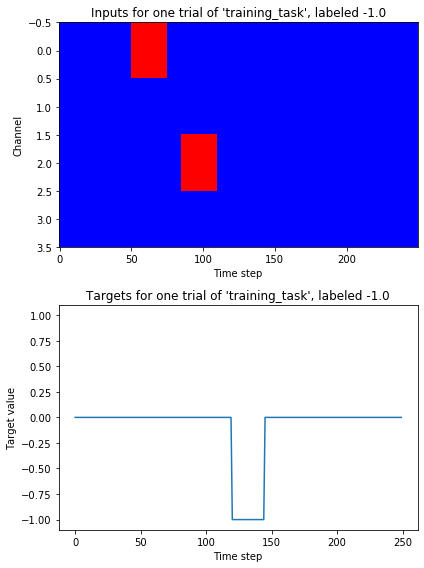

In [5]:
fig, axs = plt.subplots(2, 1, figsize=(6, 8))
axs[0].imshow(feed[ep['inputs']][0].T, aspect='auto', cmap='bwr')
axs[0].set_xlabel('Time step')
axs[0].set_ylabel('Channel')
axs[0].set_title(f"Inputs for one trial of '{scenario['name']}', labeled {feed[ep['labels']][0]}")
axs[1].plot(feed[ep['targets']][0])
axs[1].set_xlabel('Time step')
axs[1].set_ylabel('Target value')
axs[1].set_title(f"Targets for one trial of '{scenario['name']}', labeled {feed[ep['labels']][0]}")
axs[1].set_ylim(-1.1, 1.1)
plt.tight_layout()
plt.show()

In [16]:
ep

{'inputs': <tf.Tensor 'Inputs:0' shape=(64, ?, 4) dtype=float32>,
 'targets': <tf.Tensor 'Targets:0' shape=(64, ?) dtype=float32>,
 'loads': <tf.Tensor 'Loads:0' shape=(64,) dtype=int64>,
 'labels': <tf.Tensor 'Labels:0' shape=(64,) dtype=int64>,
 'z': <tf.Tensor 'rnn/transpose_1:0' shape=(64, ?, 100) dtype=float32>,
 'outs': <tf.Tensor 'Squeeze:0' shape=(64, ?) dtype=float32>,
 'accuracy': <tf.Tensor 'Mean:0' shape=() dtype=float32>}

In [17]:
feed.keys()

dict_keys([<tf.Tensor 'Inputs:0' shape=(64, ?, 4) dtype=float32>, <tf.Tensor 'Targets:0' shape=(64, ?) dtype=float32>, <tf.Tensor 'Labels:0' shape=(64,) dtype=int64>, <tf.Tensor 'Loads:0' shape=(64,) dtype=int64>])

In [23]:
spec

{'n_in': 4,
 'n_regular': 50,
 'n_adaptive': 50,
 'n_neurons': 100,
 'tau_v': 20.0,
 'tau_out': 20.0,
 'tau_a': 2000.0,
 'thr': 0.6,
 'dt': 1,
 'n_ref': 5,
 'dampening_factor': 0.3,
 'eprop': True,
 'eprop_impl': 'autodiff',
 'feedback': 'symmetric',
 'f_regularization_type': 'simple',
 't_cue_spacing': 150,
 'reg_rate_hz': 10,
 'reg_f': 1.0,
 'checkpoint_prefix': 'results/evidence_accumulation_eprop_true_20260402_204233/model.ckpt'}

Processing scenario: training_task
INFO:tensorflow:Restoring parameters from results/sternberg_eprop_true_20260402_204233/model.ckpt
Processing scenario: delay50
INFO:tensorflow:Restoring parameters from results/sternberg_eprop_true_20260402_204233/model.ckpt
Processing scenario: delay200
INFO:tensorflow:Restoring parameters from results/sternberg_eprop_true_20260402_204233/model.ckpt


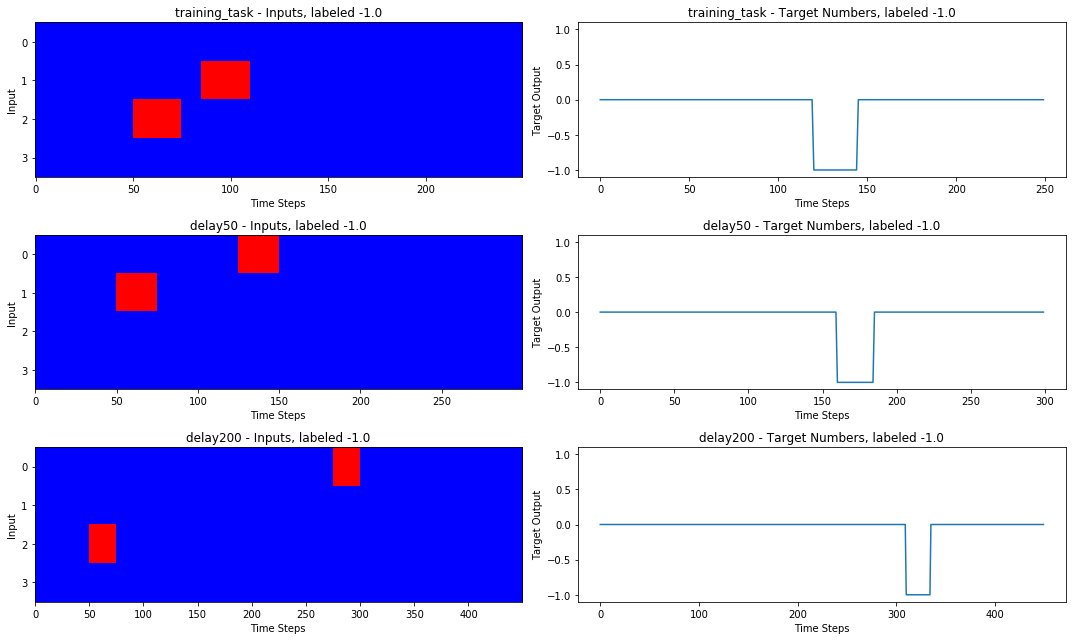

In [6]:
# Plot stimuli and targets for the first trial in each scenario.
# Use a fresh graph/session per scenario to avoid TF1 variable name collisions.

fig, axes = plt.subplots(len(trial_scenarios), 2, figsize=(15, 3 * len(trial_scenarios)))
if len(trial_scenarios) == 1:
    axes = np.array([axes])

for i, scenario in enumerate(trial_scenarios):
    print("Processing scenario:", scenario['name'])

    with tf.Graph().as_default():
        saver_local, ep_local = build_graph(spec, scenario['settings'], scenario['batch_size'])

        with tf.Session() as sess_local:
            if 'evidence_accumulation' in spec['checkpoint_prefix']:
                # change to sternberg, saved name wrong
                spec['checkpoint_prefix'] = spec['checkpoint_prefix'].replace('evidence_accumulation', 'sternberg')
            saver_local.restore(sess_local, spec['checkpoint_prefix'])

            feed_local = get_data_dict(
                batch_size=scenario['batch_size'],
                inputs=ep_local['inputs'],
                targets=ep_local['targets'],
                labels=ep_local['labels'],
                loads=ep_local['loads'],
                settings=scenario['settings'],
            )

    # Plot the first trial's inputs.
    axes[i, 0].imshow(feed_local[ep_local['inputs']][0].T, aspect='auto', cmap='bwr')
    axes[i, 0].set_title(
        f"{scenario['name']} - Inputs, labeled {feed_local[ep_local['labels']][0]}"
    )
    axes[i, 0].set_xlabel('Time Steps')
    axes[i, 0].set_ylabel('Input')

    # Plot the first trial's target numbers.
    axes[i, 1].plot(feed_local[ep_local['targets']][0])
    axes[i, 1].set_title(
        f"{scenario['name']} - Target Numbers, labeled {feed_local[ep_local['labels']][0]}"
    )
    axes[i, 1].set_xlabel('Time Steps')
    axes[i, 1].set_ylabel('Target Output')
    axes[i, 1].set_ylim(-1.1, 1.1)

plt.tight_layout()
plt.show()

## 5) Run Single-Trial Inference

INFO:tensorflow:Restoring parameters from results/sternberg_eprop_true_20260402_204233/model.ckpt
Batch accuracy: 0.953125


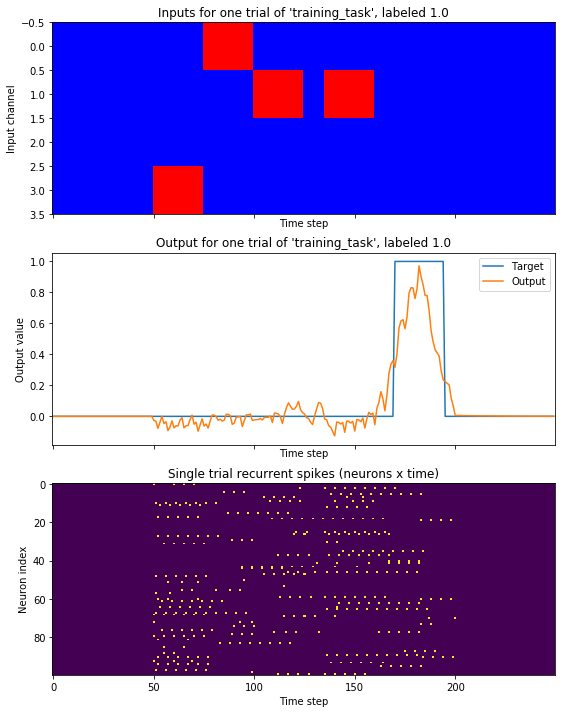

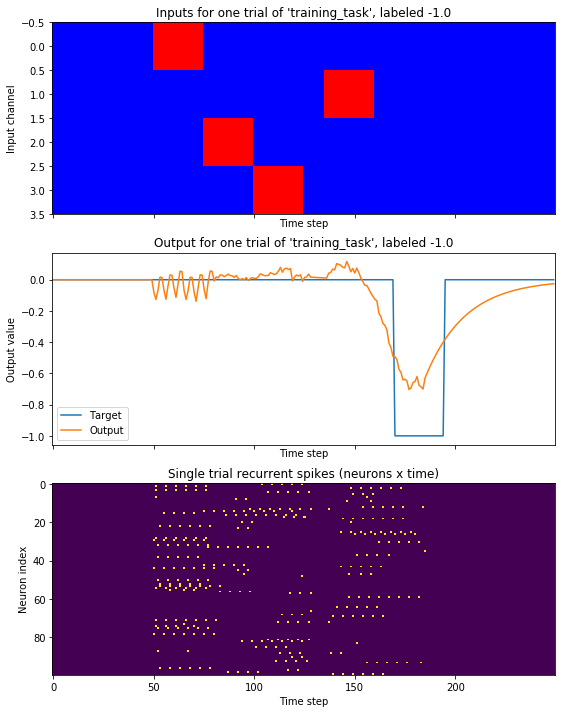

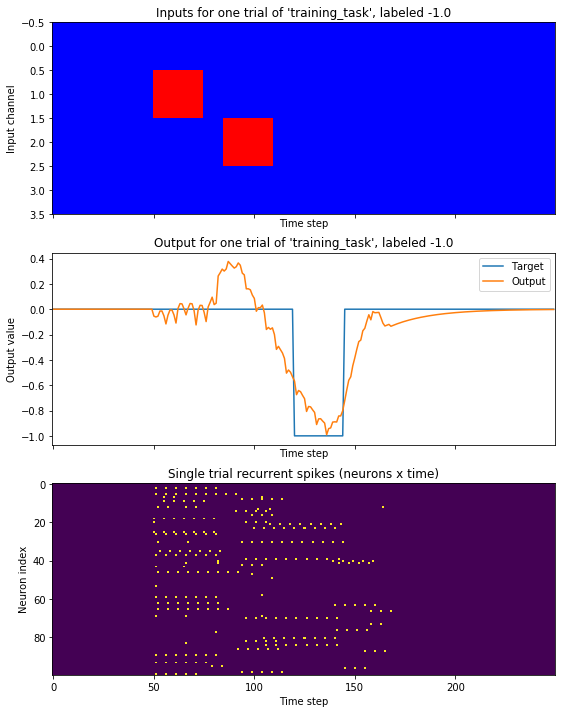

In [13]:
# Use a true single-example feed without slicing from a larger batch.
scenario = trial_scenarios[0]
settings = scenario['settings']

checkpoint_prefix = spec['checkpoint_prefix']
if 'evidence_accumulation' in checkpoint_prefix:
    # Some saved specs still contain the legacy run name prefix.
    checkpoint_prefix = checkpoint_prefix.replace('evidence_accumulation', 'sternberg')

with tf.Graph().as_default():
    saver_local, ep_local = build_graph(spec, scenario['settings'], scenario['batch_size'])

    with tf.Session() as sess_local:
        saver_local.restore(sess_local, checkpoint_prefix)

        feed_local = get_data_dict(
            batch_size=scenario['batch_size'],
            inputs=ep_local['inputs'],
            targets=ep_local['targets'],
            labels=ep_local['labels'],
            loads=ep_local['loads'],
            settings=scenario['settings'],
        )

        acc, outs, z_vals, tgt = sess_local.run(
            [ep_local['accuracy'], ep_local['outs'], ep_local['z'], ep_local['targets']],
            feed_dict=feed_local,
        )

print('Batch accuracy:', acc)

for trial_idx in range(3):
    fig, axs = plt.subplots(3, 1, figsize=(9, 12), sharex=True)

    axs[0].imshow(feed_local[ep_local['inputs']][trial_idx].T, aspect='auto', cmap='bwr')
    axs[0].set_xlabel('Time step')
    axs[0].set_ylabel('Input channel')
    axs[0].set_title(f"Inputs for one trial of '{scenario['name']}', labeled {feed_local[ep_local['labels']][trial_idx]}")

    axs[1].plot(tgt[trial_idx], label='Target')
    axs[1].plot(outs[trial_idx], label='Output')
    axs[1].set_xlabel('Time step')
    axs[1].set_ylabel('Output value')
    axs[1].set_title(f"Output for one trial of '{scenario['name']}', labeled {feed_local[ep_local['labels']][trial_idx]}")
    axs[1].legend()

    axs[2].imshow(z_vals[trial_idx].T, aspect='auto', interpolation='nearest')
    axs[2].set_xlabel('Time step')
    axs[2].set_ylabel('Neuron index')
    axs[2].set_title('Single trial recurrent spikes (neurons x time)')

    plt.show()

## 6) Run Batch Trial Inference

In [16]:
records = []
per_scenario_payload = {}
N_EVAL_BATCHES = 4

for scenario in trial_scenarios:
    payload = {
        'inputs': [],
        'targets': [],
        'outputs': [],
        'spikes': [],
    }

    scenario_batch_size = int(scenario.get('batch_size', 64))
    
    with tf.Graph().as_default():
        
        saver_local, ep_local = build_graph(spec, scenario['settings'], scenario['batch_size'])

        checkpoint_prefix = spec['checkpoint_prefix']
        if 'evidence_accumulation' in checkpoint_prefix:
            # Some saved specs still contain the legacy run name prefix.
            checkpoint_prefix = checkpoint_prefix.replace('evidence_accumulation', 'sternberg')

        with tf.Session() as sess_local:
            saver_local.restore(sess_local, checkpoint_prefix)

            for batch_idx in range(N_EVAL_BATCHES):
                feed_local = get_data_dict(
                    batch_size=scenario['batch_size'],
                    inputs=ep_local['inputs'],
                    targets=ep_local['targets'],
                    labels=ep_local['labels'],
                    loads=ep_local['loads'],
                    settings=scenario['settings'],
                )

                acc, outs, z_vals, tgt = sess_local.run(
                    [ep_local['accuracy'], ep_local['outs'], ep_local['z'], ep_local['targets']],
                    feed_dict=feed_local,
                )

                records.append({
                    'scenario': scenario['name'],
                    'batch_idx': batch_idx,
                    'accuracy': float(acc),
                    'n_batch': scenario_batch_size,
                })

                payload['outputs'].append(outs)
                payload['targets'].append(tgt)
                payload['spikes'].append(z_vals)
                payload['inputs'].append(feed_local[ep_local['inputs']])

            per_scenario_payload[scenario['name']] = payload

    results_df = pd.DataFrame(records)
    results_df

INFO:tensorflow:Restoring parameters from results/sternberg_eprop_true_20260402_204233/model.ckpt
INFO:tensorflow:Restoring parameters from results/sternberg_eprop_true_20260402_204233/model.ckpt
INFO:tensorflow:Restoring parameters from results/sternberg_eprop_true_20260402_204233/model.ckpt


In [17]:
results_df

,scenario,batch_idx,accuracy,n_batch
0,training_task,0,0.953125,64
1,training_task,1,0.953125,64
2,training_task,2,0.953125,64
3,training_task,3,0.953125,64
4,delay50,0,0.468750,64
5,delay50,1,0.375000,64
6,delay50,2,0.546875,64
7,delay50,3,0.625000,64
8,delay200,0,0.515625,64
9,delay200,1,0.468750,64


Scenario: training_task
Outputs shape: (4, 64, 250)
Targets shape: (4, 64, 250)
Spikes shape: (4, 64, 250, 100)
Inputs shape: (4, 64, 250, 4)


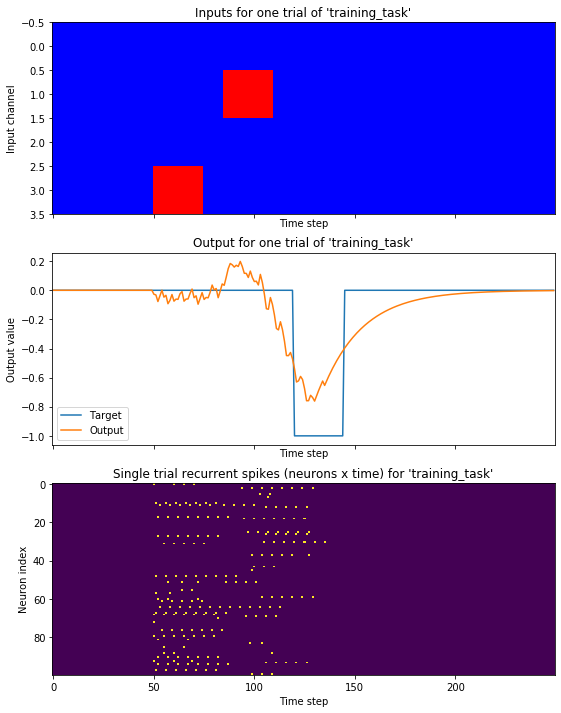

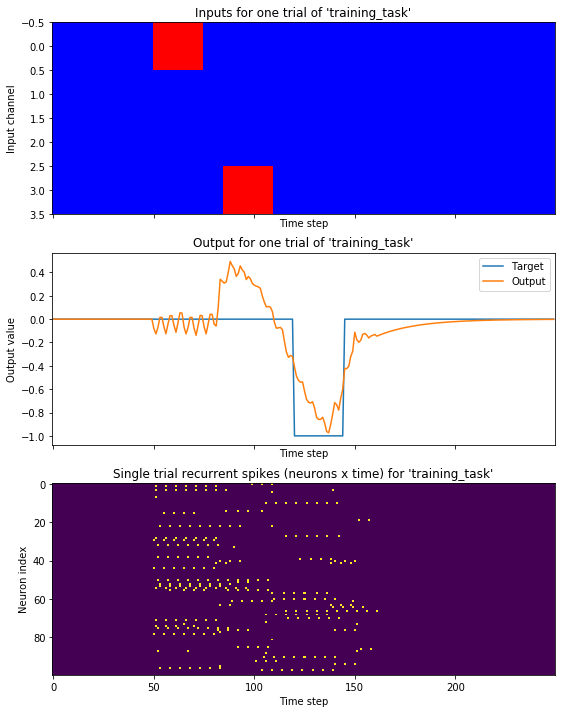

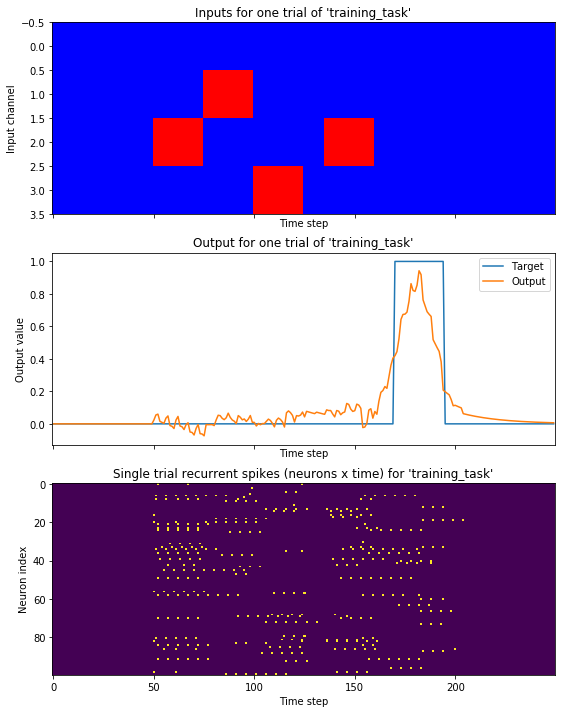

Scenario: delay50
Outputs shape: (4, 64, 300)
Targets shape: (4, 64, 300)
Spikes shape: (4, 64, 300, 100)
Inputs shape: (4, 64, 300, 4)


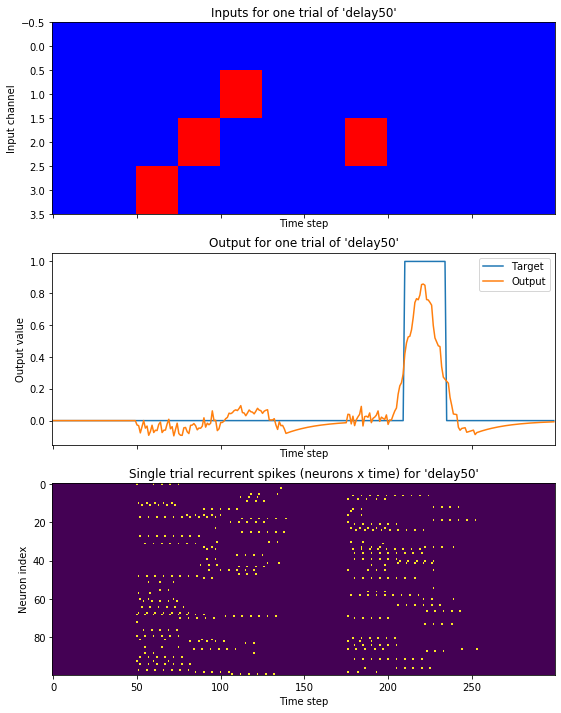

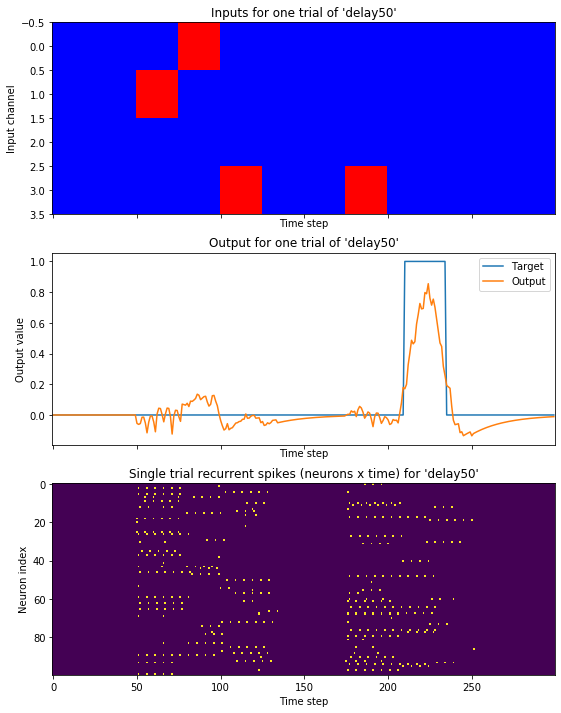

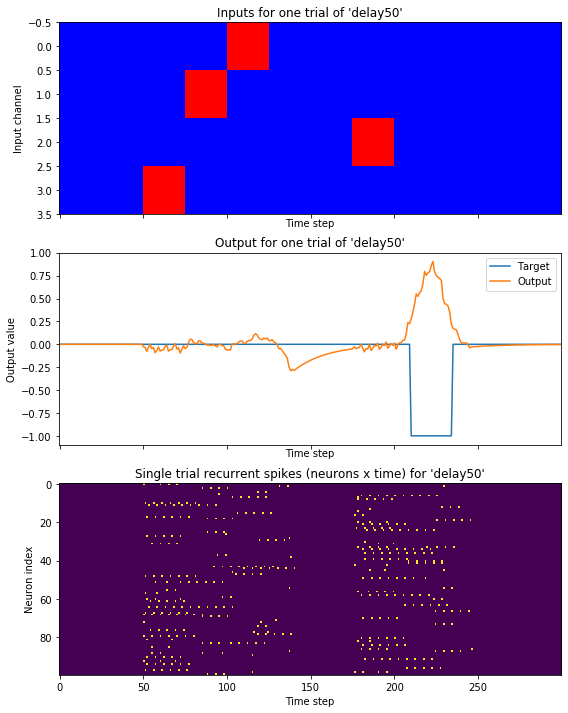

Scenario: delay200
Outputs shape: (4, 64, 450)
Targets shape: (4, 64, 450)
Spikes shape: (4, 64, 450, 100)
Inputs shape: (4, 64, 450, 4)


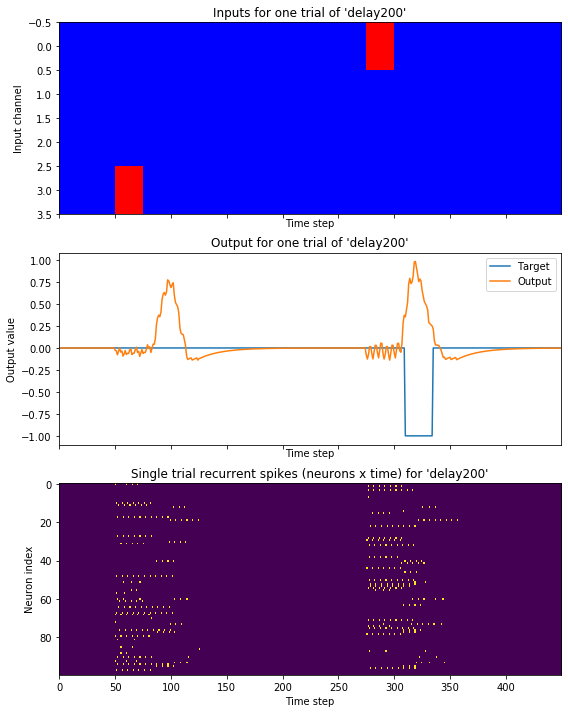

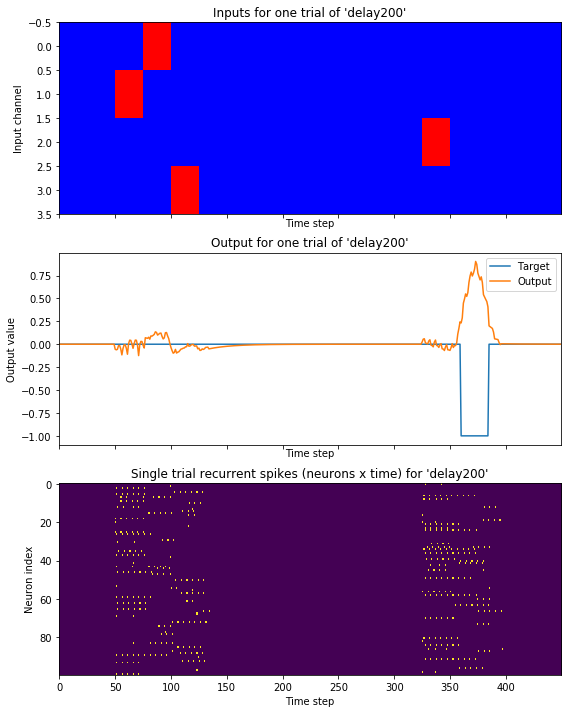

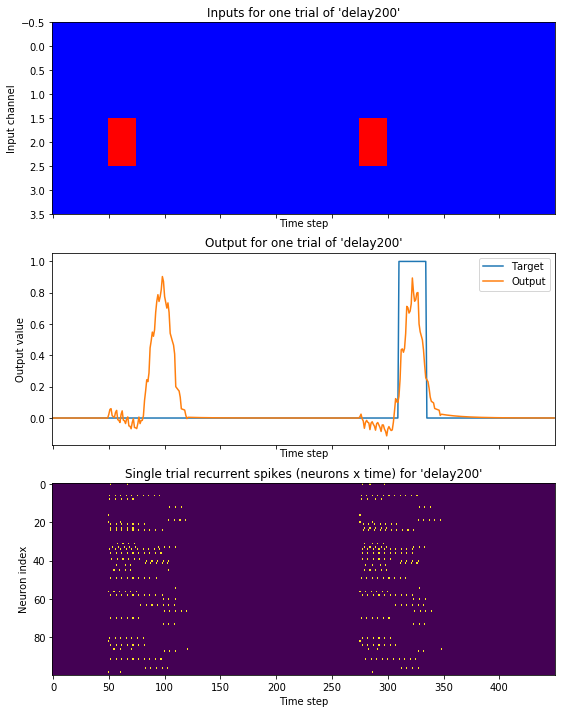

In [25]:
# plot per_scenario_payload, or just payload

for scenario_name, payload in per_scenario_payload.items():
    print(f"Scenario: {scenario_name}")
    print("Outputs shape:", np.array(payload['outputs']).shape)
    print("Targets shape:", np.array(payload['targets']).shape)
    print("Spikes shape:", np.array(payload['spikes']).shape)
    print("Inputs shape:", np.array(payload['inputs']).shape)

    outputs = payload['outputs']
    targets = payload['targets']
    spikes = payload['spikes']
    inputs = payload['inputs']

    for trial_idx in range(3):
        fig, axs = plt.subplots(3, 1, figsize=(9, 12), sharex=True)

        axs[0].imshow(inputs[0][trial_idx,:,:].T, aspect='auto', cmap='bwr')
        axs[0].set_xlabel('Time step')
        axs[0].set_ylabel('Input channel')
        axs[0].set_title(f"Inputs for one trial of '{scenario_name}'")

        axs[1].plot(targets[0][trial_idx,:], label='Target')
        axs[1].plot(outputs[0][trial_idx,:], label='Output')
        axs[1].set_xlabel('Time step')
        axs[1].set_ylabel('Output value')
        axs[1].set_title(f"Output for one trial of '{scenario_name}'")
        axs[1].legend()

        axs[2].imshow(spikes[0][trial_idx,:,:].T, aspect='auto', interpolation='nearest')
        axs[2].set_xlabel('Time step')
        axs[2].set_ylabel('Neuron index')
        axs[2].set_title(f"Single trial recurrent spikes (neurons x time) for '{scenario_name}'")

        plt.show()


# Now the other model

In [5]:
# Pick your saved run folder manually, or leave AUTO to use the newest.
RUNS_ROOT = NB_DIR / 'results'
MODEL_SPEC_PATH = '/home/nuttidalab/Documents/renee/eligibility_propagation/sternberg_training/results/sternberg_eprop_true_20260402_203429/model_spec.json'  # Example: NB_DIR / 'results' / 'evidence_accumulation_eprop_true_20260401_120000' / 'model_spec.json'

if MODEL_SPEC_PATH is None:
    spec_paths = sorted(RUNS_ROOT.glob('sternberg_eprop_*/model_spec.json'))
    if not spec_paths:
        raise FileNotFoundError(f'No model_spec.json found under {RUNS_ROOT}')
    MODEL_SPEC_PATH = spec_paths[-1]

MODEL_SPEC_PATH = Path(MODEL_SPEC_PATH)
spec = load_model_spec(str(MODEL_SPEC_PATH))

N_BATCH = 64

sess = tf.Session()
sess.run(tf.global_variables_initializer())

print('Loaded model spec:', MODEL_SPEC_PATH)
print('Checkpoint prefix:', spec['checkpoint_prefix'])

# resave the spec with the correct checkpoint prefix if it was changed in the code above
if 'evidence_accumulation' in spec['checkpoint_prefix']:
    # change to sternberg, saved name wrong
    spec['checkpoint_prefix'] = spec['checkpoint_prefix'].replace('evidence_accumulation', 'sternberg')
    with open(MODEL_SPEC_PATH, 'w') as f:
        json.dump(spec, f, indent=4)

print('eprop mode from spec:', spec.get('eprop', False))

Loaded model spec: /home/nuttidalab/Documents/renee/eligibility_propagation/sternberg_training/results/sternberg_eprop_true_20260402_203429/model_spec.json
Checkpoint prefix: results/evidence_accumulation_eprop_true_20260402_203429/model.ckpt
eprop mode from spec: True


## 4) Prepare Trial Inputs for Inference

In [6]:
# Start from default scenarios from the script, then edit/add your own here.
trial_scenarios = get_trial_scenarios(spec)

# Add an explicit batch size per scenario to leverage dynamic-batch placeholders.
for s in trial_scenarios:
    s['batch_size'] = 64

print('Scenarios to run:', [(s['name'], s['batch_size']) for s in trial_scenarios])

# Build one feed dict for sanity checks.
scenario = trial_scenarios[0]
settings = scenario['settings']

saver, ep = build_graph(spec, scenario['settings'], scenario['batch_size'])

feed = get_data_dict(
    batch_size=scenario['batch_size'],
    inputs=ep['inputs'],
    targets=ep['targets'],
    labels=ep['labels'],
    loads=ep['loads'],
    settings=scenario['settings'],
)

print('Input shape:', feed[ep['inputs']].shape)
print('Target shape:', feed[ep['targets']].shape)
print('Input dtype:', feed[ep['inputs']].dtype)

Scenarios to run: [('training_task', 64), ('delay50', 64), ('delay200', 64)]

Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
Instructions for updating:
Please use `keras.layers.RNN(cell)`, which is equivalent to this API
Input shape: (64, 250, 4)
Target shape: (64, 250)
Input dtype: float64


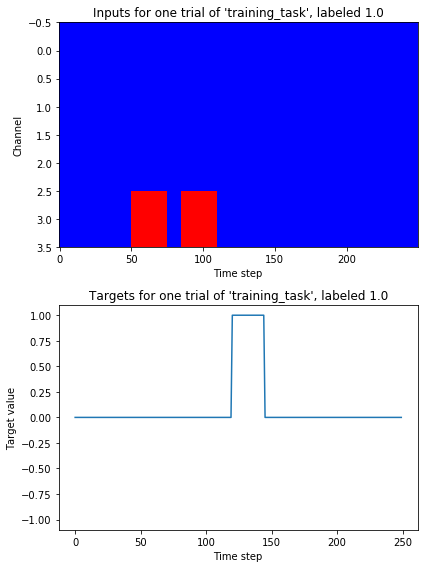

In [7]:
fig, axs = plt.subplots(2, 1, figsize=(6, 8))
axs[0].imshow(feed[ep['inputs']][0].T, aspect='auto', cmap='bwr')
axs[0].set_xlabel('Time step')
axs[0].set_ylabel('Channel')
axs[0].set_title(f"Inputs for one trial of '{scenario['name']}', labeled {feed[ep['labels']][0]}")
axs[1].plot(feed[ep['targets']][0])
axs[1].set_xlabel('Time step')
axs[1].set_ylabel('Target value')
axs[1].set_title(f"Targets for one trial of '{scenario['name']}', labeled {feed[ep['labels']][0]}")
axs[1].set_ylim(-1.1, 1.1)
plt.tight_layout()
plt.show()

Processing scenario: training_task
INFO:tensorflow:Restoring parameters from results/sternberg_eprop_true_20260402_203429/model.ckpt
Processing scenario: delay50
INFO:tensorflow:Restoring parameters from results/sternberg_eprop_true_20260402_203429/model.ckpt
Processing scenario: delay200
INFO:tensorflow:Restoring parameters from results/sternberg_eprop_true_20260402_203429/model.ckpt


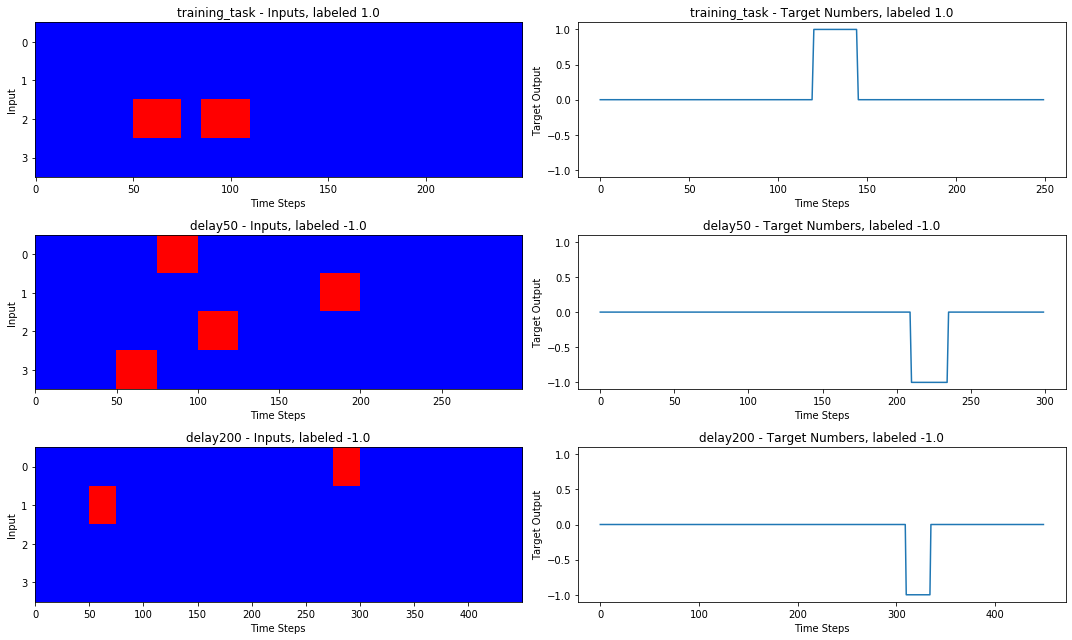

In [8]:
# Plot stimuli and targets for the first trial in each scenario.
# Use a fresh graph/session per scenario to avoid TF1 variable name collisions.

fig, axes = plt.subplots(len(trial_scenarios), 2, figsize=(15, 3 * len(trial_scenarios)))
if len(trial_scenarios) == 1:
    axes = np.array([axes])

for i, scenario in enumerate(trial_scenarios):
    print("Processing scenario:", scenario['name'])

    with tf.Graph().as_default():
        saver_local, ep_local = build_graph(spec, scenario['settings'], scenario['batch_size'])

        with tf.Session() as sess_local:
            if 'evidence_accumulation' in spec['checkpoint_prefix']:
                # change to sternberg, saved name wrong
                spec['checkpoint_prefix'] = spec['checkpoint_prefix'].replace('evidence_accumulation', 'sternberg')
            saver_local.restore(sess_local, spec['checkpoint_prefix'])

            feed_local = get_data_dict(
                batch_size=scenario['batch_size'],
                inputs=ep_local['inputs'],
                targets=ep_local['targets'],
                labels=ep_local['labels'],
                loads=ep_local['loads'],
                settings=scenario['settings'],
            )

    # Plot the first trial's inputs.
    axes[i, 0].imshow(feed_local[ep_local['inputs']][0].T, aspect='auto', cmap='bwr')
    axes[i, 0].set_title(
        f"{scenario['name']} - Inputs, labeled {feed_local[ep_local['labels']][0]}"
    )
    axes[i, 0].set_xlabel('Time Steps')
    axes[i, 0].set_ylabel('Input')

    # Plot the first trial's target numbers.
    axes[i, 1].plot(feed_local[ep_local['targets']][0])
    axes[i, 1].set_title(
        f"{scenario['name']} - Target Numbers, labeled {feed_local[ep_local['labels']][0]}"
    )
    axes[i, 1].set_xlabel('Time Steps')
    axes[i, 1].set_ylabel('Target Output')
    axes[i, 1].set_ylim(-1.1, 1.1)

plt.tight_layout()
plt.show()

## 5) Run Single-Trial Inference

INFO:tensorflow:Restoring parameters from results/sternberg_eprop_true_20260402_203429/model.ckpt
Batch accuracy: 0.921875


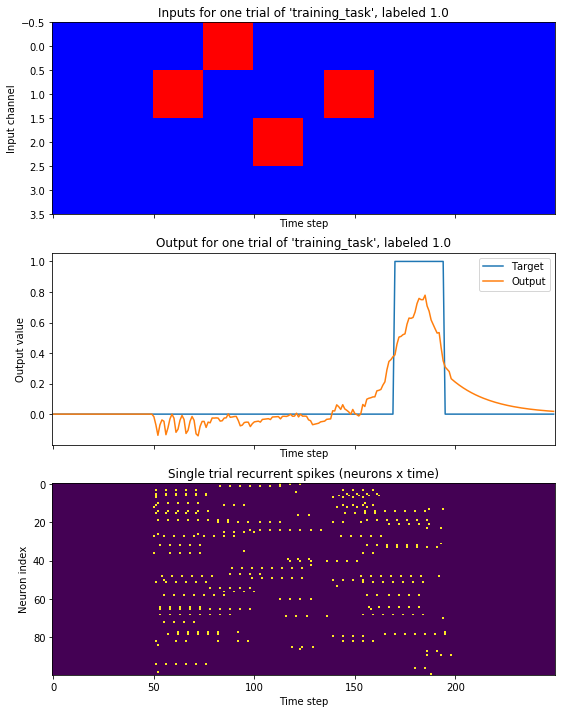

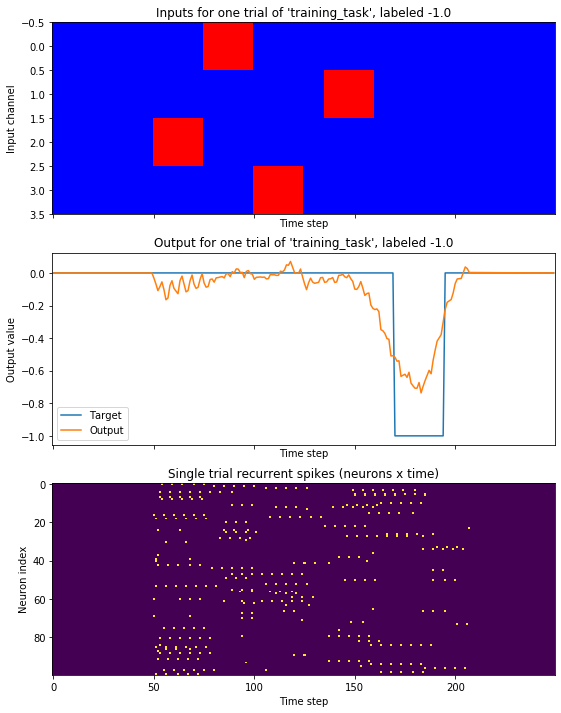

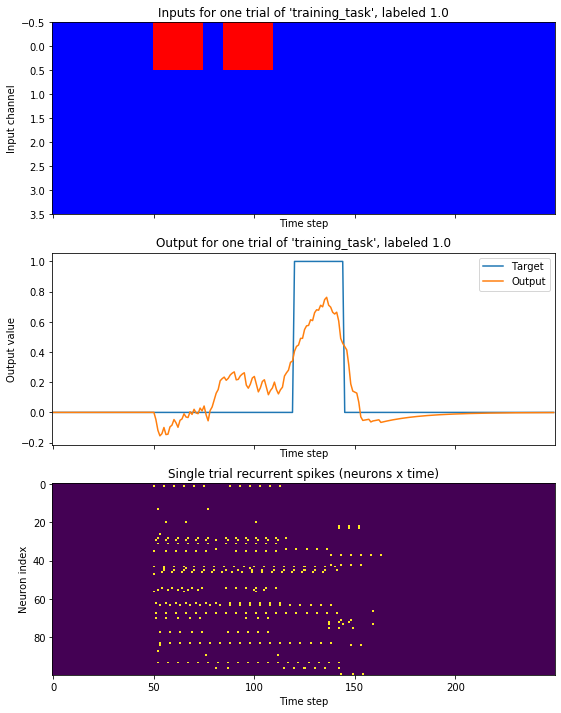

In [9]:
# Use a true single-example feed without slicing from a larger batch.
scenario = trial_scenarios[0]
settings = scenario['settings']

checkpoint_prefix = spec['checkpoint_prefix']
if 'evidence_accumulation' in checkpoint_prefix:
    # Some saved specs still contain the legacy run name prefix.
    checkpoint_prefix = checkpoint_prefix.replace('evidence_accumulation', 'sternberg')

with tf.Graph().as_default():
    saver_local, ep_local = build_graph(spec, scenario['settings'], scenario['batch_size'])

    with tf.Session() as sess_local:
        saver_local.restore(sess_local, checkpoint_prefix)

        feed_local = get_data_dict(
            batch_size=scenario['batch_size'],
            inputs=ep_local['inputs'],
            targets=ep_local['targets'],
            labels=ep_local['labels'],
            loads=ep_local['loads'],
            settings=scenario['settings'],
        )

        acc, outs, z_vals, tgt = sess_local.run(
            [ep_local['accuracy'], ep_local['outs'], ep_local['z'], ep_local['targets']],
            feed_dict=feed_local,
        )

print('Batch accuracy:', acc)

for trial_idx in range(3):
    fig, axs = plt.subplots(3, 1, figsize=(9, 12), sharex=True)

    axs[0].imshow(feed_local[ep_local['inputs']][trial_idx].T, aspect='auto', cmap='bwr')
    axs[0].set_xlabel('Time step')
    axs[0].set_ylabel('Input channel')
    axs[0].set_title(f"Inputs for one trial of '{scenario['name']}', labeled {feed_local[ep_local['labels']][trial_idx]}")

    axs[1].plot(tgt[trial_idx], label='Target')
    axs[1].plot(outs[trial_idx], label='Output')
    axs[1].set_xlabel('Time step')
    axs[1].set_ylabel('Output value')
    axs[1].set_title(f"Output for one trial of '{scenario['name']}', labeled {feed_local[ep_local['labels']][trial_idx]}")
    axs[1].legend()

    axs[2].imshow(z_vals[trial_idx].T, aspect='auto', interpolation='nearest')
    axs[2].set_xlabel('Time step')
    axs[2].set_ylabel('Neuron index')
    axs[2].set_title('Single trial recurrent spikes (neurons x time)')

    plt.show()

## 6) Run Batch Trial Inference

In [10]:
records = []
per_scenario_payload = {}
N_EVAL_BATCHES = 4

for scenario in trial_scenarios:
    payload = {
        'inputs': [],
        'targets': [],
        'outputs': [],
        'spikes': [],
    }

    scenario_batch_size = int(scenario.get('batch_size', 64))
    
    with tf.Graph().as_default():
        
        saver_local, ep_local = build_graph(spec, scenario['settings'], scenario['batch_size'])

        checkpoint_prefix = spec['checkpoint_prefix']
        if 'evidence_accumulation' in checkpoint_prefix:
            # Some saved specs still contain the legacy run name prefix.
            checkpoint_prefix = checkpoint_prefix.replace('evidence_accumulation', 'sternberg')

        with tf.Session() as sess_local:
            saver_local.restore(sess_local, checkpoint_prefix)

            for batch_idx in range(N_EVAL_BATCHES):
                feed_local = get_data_dict(
                    batch_size=scenario['batch_size'],
                    inputs=ep_local['inputs'],
                    targets=ep_local['targets'],
                    labels=ep_local['labels'],
                    loads=ep_local['loads'],
                    settings=scenario['settings'],
                )

                acc, outs, z_vals, tgt = sess_local.run(
                    [ep_local['accuracy'], ep_local['outs'], ep_local['z'], ep_local['targets']],
                    feed_dict=feed_local,
                )

                records.append({
                    'scenario': scenario['name'],
                    'batch_idx': batch_idx,
                    'accuracy': float(acc),
                    'n_batch': scenario_batch_size,
                })

                payload['outputs'].append(outs)
                payload['targets'].append(tgt)
                payload['spikes'].append(z_vals)
                payload['inputs'].append(feed_local[ep_local['inputs']])

            per_scenario_payload[scenario['name']] = payload

    results_df = pd.DataFrame(records)
    results_df

INFO:tensorflow:Restoring parameters from results/sternberg_eprop_true_20260402_203429/model.ckpt
INFO:tensorflow:Restoring parameters from results/sternberg_eprop_true_20260402_203429/model.ckpt
INFO:tensorflow:Restoring parameters from results/sternberg_eprop_true_20260402_203429/model.ckpt


In [11]:
results_df

,scenario,batch_idx,accuracy,n_batch
0,training_task,0,0.937500,64
1,training_task,1,0.890625,64
2,training_task,2,0.937500,64
3,training_task,3,0.953125,64
4,delay50,0,0.468750,64
5,delay50,1,0.406250,64
6,delay50,2,0.343750,64
7,delay50,3,0.390625,64
8,delay200,0,0.390625,64
9,delay200,1,0.421875,64


Scenario: training_task
Outputs shape: (4, 64, 250)
Targets shape: (4, 64, 250)
Spikes shape: (4, 64, 250, 100)
Inputs shape: (4, 64, 250, 4)


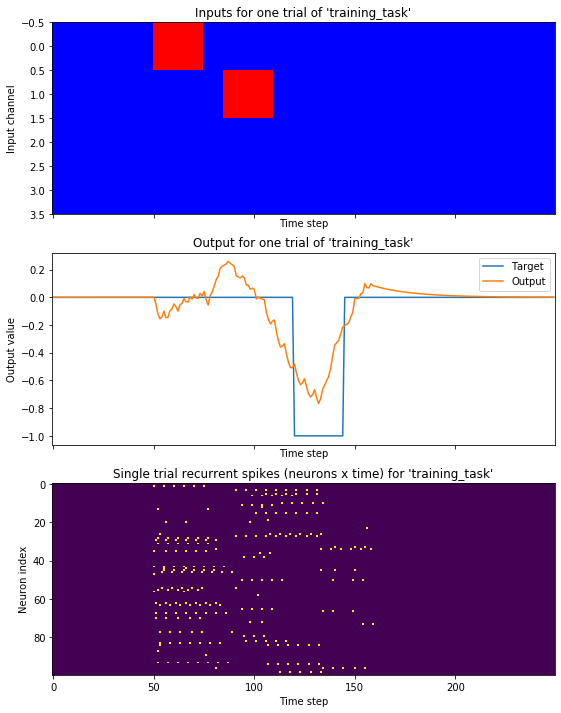

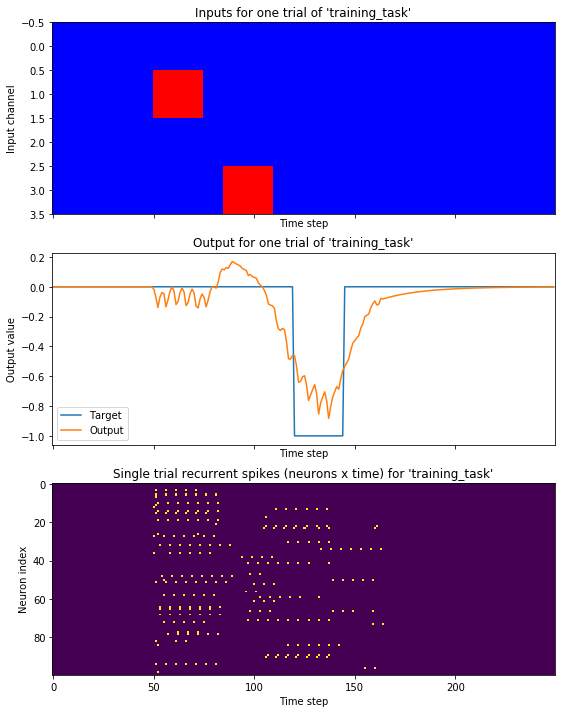

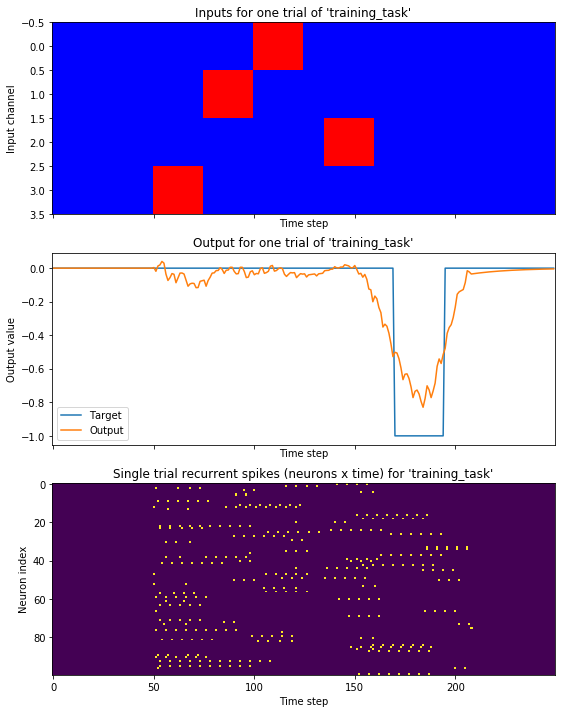

Scenario: delay50
Outputs shape: (4, 64, 300)
Targets shape: (4, 64, 300)
Spikes shape: (4, 64, 300, 100)
Inputs shape: (4, 64, 300, 4)


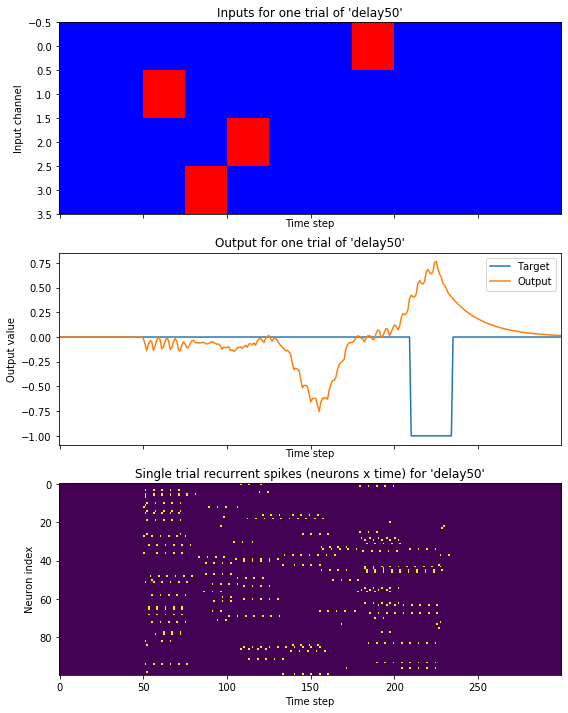

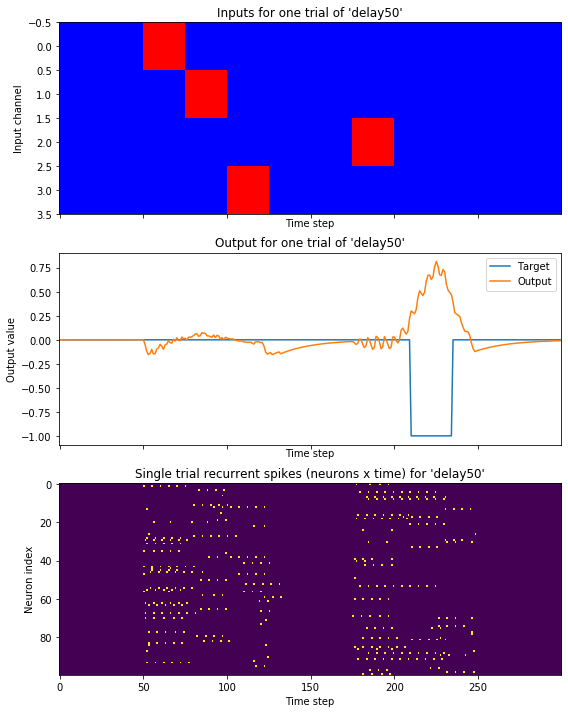

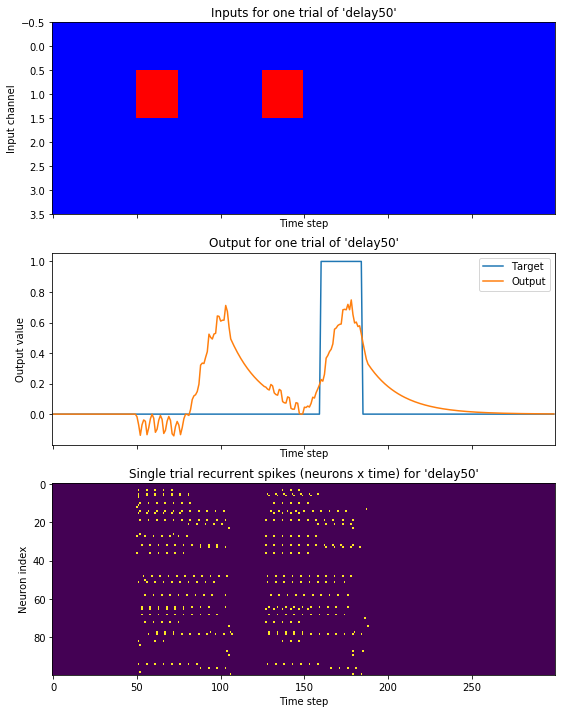

Scenario: delay200
Outputs shape: (4, 64, 450)
Targets shape: (4, 64, 450)
Spikes shape: (4, 64, 450, 100)
Inputs shape: (4, 64, 450, 4)


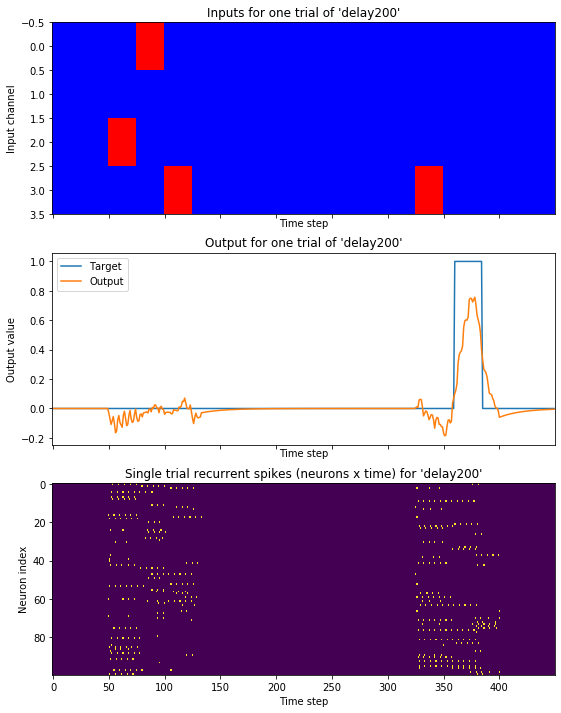

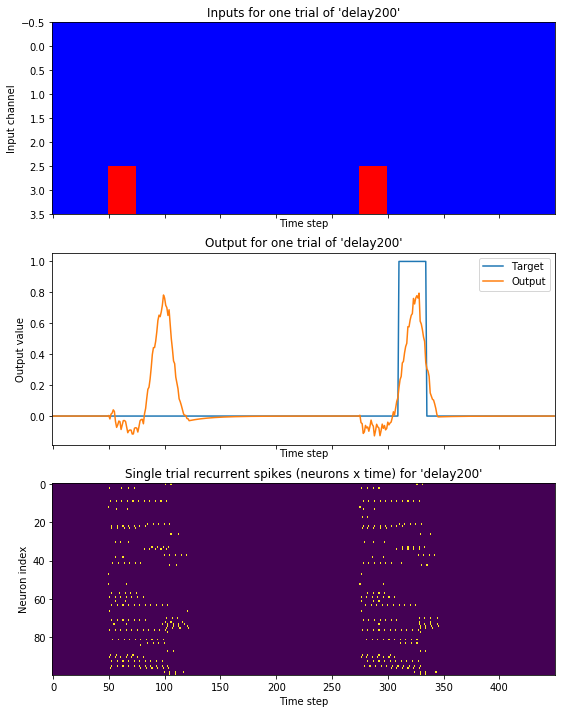

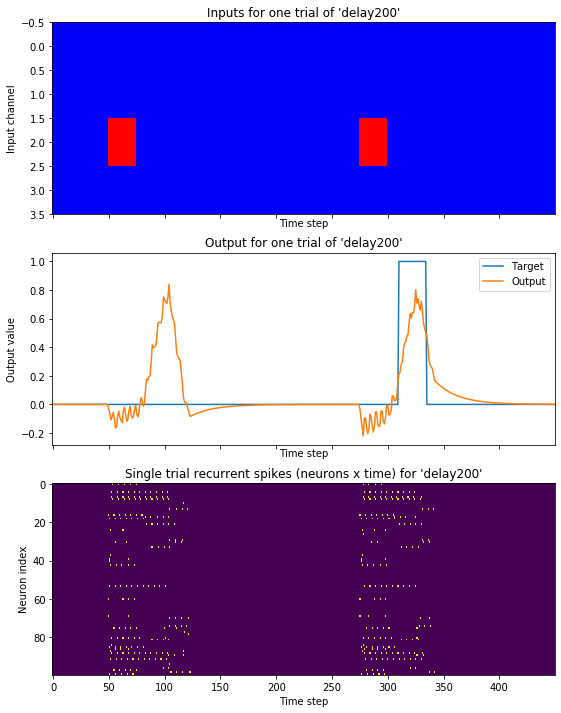

In [12]:
# plot per_scenario_payload, or just payload

for scenario_name, payload in per_scenario_payload.items():
    print(f"Scenario: {scenario_name}")
    print("Outputs shape:", np.array(payload['outputs']).shape)
    print("Targets shape:", np.array(payload['targets']).shape)
    print("Spikes shape:", np.array(payload['spikes']).shape)
    print("Inputs shape:", np.array(payload['inputs']).shape)

    outputs = payload['outputs']
    targets = payload['targets']
    spikes = payload['spikes']
    inputs = payload['inputs']

    for trial_idx in range(3):
        fig, axs = plt.subplots(3, 1, figsize=(9, 12), sharex=True)

        axs[0].imshow(inputs[0][trial_idx,:,:].T, aspect='auto', cmap='bwr')
        axs[0].set_xlabel('Time step')
        axs[0].set_ylabel('Input channel')
        axs[0].set_title(f"Inputs for one trial of '{scenario_name}'")

        axs[1].plot(targets[0][trial_idx,:], label='Target')
        axs[1].plot(outputs[0][trial_idx,:], label='Output')
        axs[1].set_xlabel('Time step')
        axs[1].set_ylabel('Output value')
        axs[1].set_title(f"Output for one trial of '{scenario_name}'")
        axs[1].legend()

        axs[2].imshow(spikes[0][trial_idx,:,:].T, aspect='auto', interpolation='nearest')
        axs[2].set_xlabel('Time step')
        axs[2].set_ylabel('Neuron index')
        axs[2].set_title(f"Single trial recurrent spikes (neurons x time) for '{scenario_name}'")

        plt.show()
